## Practice Lecture 17 - Deep Neural Networks
In this lab we will use Dimensionality Reduction methods for classification. \
Based on Chapter 10 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice17_DNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


### Exercise 1: Classification with the Perceptron
Use scikit-learn to create a perceptron to classify the iris data set (single classification).\
Convert the data to binary classification (y==0 True, all others False).\
Use the Percetron in sklearn to obtain the values of the line that separates the two classes and plot them in one graphics


In [2]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
X = iris.data[:,(2,3)]
y = iris.target

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
print(y.shape)
print(y.dtype)
print(y)

(150,)
int64
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [6]:
y2 = (iris.target == 0).astype(np.int)

In [7]:
print(y2.dtype)
print(y2)

int64
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [8]:
pct=Perceptron()
pct.fit(X,y2)

Perceptron(alpha=0.0001, class_weight=None, early_stopping=False, eta0=1.0,
           fit_intercept=True, max_iter=1000, n_iter_no_change=5, n_jobs=None,
           penalty=None, random_state=0, shuffle=True, tol=0.001,
           validation_fraction=0.1, verbose=0, warm_start=False)

(1, 2)
(1,)
(150, 2)
(150,)
[[-0.7 -1.2]]
[2.]


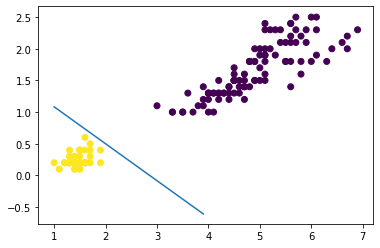

In [9]:
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y2)
a=pct.coef_
b=pct.intercept_
print(a.shape)
print(b.shape)
print(X.shape)
print(y.shape)
print(a)
print(b)
m=-(a[0,0]/a[0,1])
b=-(b[0]/a[0,1])
x=np.arange(1,4,0.1)
plt.plot(x,m*x+b)

### Exercise 2: Sequential Neural Network with MNIST
Build a classifier with keras for the MNIST data set.\
HINT: convert integer values in pixels to floats between 0-1

In [10]:
from tensorflow import keras
import tensorflow as tf

In [11]:
mnist = keras.datasets.mnist

In [12]:
(X,y),(Xt,yt) = mnist.load_data()
X=X/255.
Xt=Xt/255.
Xv=X[50001:]
yv=y[50001:]
X=X[:50000]
y=y[:50000]
print(X.shape,y.shape,Xt.shape,yt.shape)

(50000, 28, 28) (50000,) (10000, 28, 28) (10000,)


In [13]:
print(X.shape,y.shape,Xv.shape,yv.shape,Xt.shape,yt.shape)

(50000, 28, 28) (50000,) (9999, 28, 28) (9999,) (10000, 28, 28) (10000,)


5


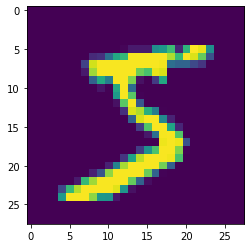

In [14]:
plt.figure()
plt.imshow(X[0])
print(y[0])

Build a sequential fully connected network. Because the output is multiclass we need "softmax" in output.

In [15]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [17]:
# number of parameters for each layer
def nparam(ninput, nneurons):
    return (ninput+1)*nneurons
print(nparam(784,300))
print(nparam(300,100))
print(nparam(100,10))

235500
30100
1010


Use sparse_categorical_crossentropy because:
classes are sparse (1 in 10)
categorical because classes are exclusive
crossentropy is typical for classification

In [18]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [19]:
niter=10
history=model.fit(X,y,epochs=niter,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 4s 73us/sample - loss: 0.6616 - accuracy: 0.8334 - val_loss: 0.3112 - val_accuracy: 0.9139
Epoch 2/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2980 - accuracy: 0.9163 - val_loss: 0.2530 - val_accuracy: 0.9289
Epoch 3/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.2445 - accuracy: 0.9297 - val_loss: 0.2084 - val_accuracy: 0.9422
Epoch 4/10
50000/50000 [==============================] - 3s 62us/sample - loss: 0.2098 - accuracy: 0.9404 - val_loss: 0.1928 - val_accuracy: 0.9480
Epoch 5/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1841 - accuracy: 0.9475 - val_loss: 0.1694 - val_accuracy: 0.9538
Epoch 6/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1644 - accuracy: 0.9524 - val_loss: 0.1545 - val_accuracy: 0.9567
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


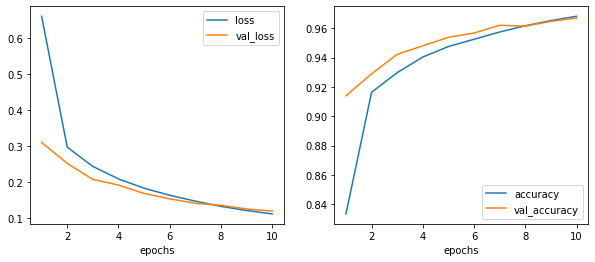

In [20]:
history.params.items
def printhistory(history):
    niter=history.params['epochs']
    print(history.history.keys())
    iter=np.arange(niter)+1
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.plot(iter,history.history['loss'],label='loss')
    plt.plot(iter,history.history['val_loss'],label='val_loss')
    plt.xlabel('epochs')
    plt.legend()
    plt.subplot(122)
    plt.plot(iter,history.history['accuracy'],label='accuracy')
    plt.plot(iter,history.history['val_accuracy'],label='val_accuracy')
    plt.xlabel('epochs')
    plt.legend()
printhistory(history)

In [21]:
model.evaluate(Xt,yt)

10000/10000 [==============================] - 0s 44us/sample - loss: 0.1200 - accuracy: 0.9648


[0.11998268775418401, 0.9648]

In [22]:
model.evaluate(Xt[:3],yt[:3])

3/3 [==============================] - 0s 882us/sample - loss: 0.0124 - accuracy: 1.0000


[0.012445821426808834, 1.0]

In [23]:
print(yt[:3])

[7 2 1]


(<matplotlib.axes._subplots.AxesSubplot at 0x7fb3e6055150>,
 <matplotlib.image.AxesImage at 0x7fb3c82f3e10>)

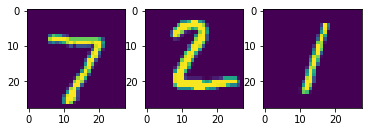

In [24]:
plt.figure()
plt.subplot(131),plt.imshow(Xt[0])
plt.subplot(132),plt.imshow(Xt[1])
plt.subplot(133),plt.imshow(Xt[2])

The evaluate method gives the most probable class. We can see probabilities for each class using predict()

In [25]:
Xnew=Xt[1:20]
ynew=yt[1:20]
yproba=model.predict(Xnew)

In [26]:
print(yproba.round(2))

[[0.   0.   0.98 0.01 0.   0.   0.   0.   0.01 0.  ]
 [0.   0.99 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.99 0.   0.   0.   0.   0.01]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.98 0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.99]
 [0.   0.   0.   0.   0.   0.02 0.97 0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.01 0.   0.98]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.99 0.   0.01 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.99]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.03 0.   0.96 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.99]
 [0.   0.   0.   0.   0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.08 0.73 0.   0.   0.01 0.   0.18 0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.  

In [27]:
yproba2=model.predict_classes(Xnew)
print(yproba2)

[2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


In [28]:
print(ynew)

[2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [29]:
print(yproba2-ynew)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
print(np.argmax(yproba2-ynew))

7


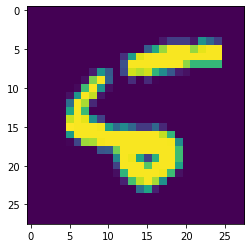

In [31]:
plt.imshow(Xnew[7])

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [33]:
hidden1 = model.layers[1]
print(hidden1.name)
model.get_layer(hidden1.name) is hidden1

dense


True

In [34]:
weights, biases = hidden1.get_weights()

In [35]:
print(weights.shape, biases.shape)

(784, 300) (300,)


In [36]:
print(weights[0,:10])
print(biases[:10])

[-0.04635838  0.03431157 -0.05620494  0.02134385  0.0215171   0.0508952
 -0.06202509  0.04703406  0.03063983  0.00274197]
[ 0.01300872  0.00608714  0.02592319  0.02375459  0.03443226  0.0215365
 -0.00428866  0.00924223  0.0421628  -0.01480618]


### Exercise 3: Functional API
Write the same problem as exercise 2 but using Functional API

In [37]:
print(X[:].flatten().shape)

(39200000,)


In [38]:
input_ = keras.layers.Input(shape=(28,28))
inputf_ = keras.layers.Flatten(input_shape=[28,28])(input_)
hidden1 = keras.layers.Dense(300, activation="relu")(inputf_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
output = keras.layers.Dense(10,activation="softmax")(hidden2)
model = keras.models.Model(inputs=[input_], outputs=[output])

In [39]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28)]          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [40]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [41]:
model.fit(X,y,epochs=10,validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.6286 - accuracy: 0.8373 - val_loss: 0.3043 - val_accuracy: 0.9153
Epoch 2/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2968 - accuracy: 0.9156 - val_loss: 0.2455 - val_accuracy: 0.9298
Epoch 3/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.2443 - accuracy: 0.9302 - val_loss: 0.2142 - val_accuracy: 0.9403
Epoch 4/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.2107 - accuracy: 0.9396 - val_loss: 0.1871 - val_accuracy: 0.9491
Epoch 5/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1850 - accuracy: 0.9473 - val_loss: 0.1831 - val_accuracy: 0.9482
Epoch 6/10
50000/50000 [==============================] - 3s 61us/sample - loss: 0.1648 - accuracy: 0.9523 - val_loss: 0.1582 - val_accuracy: 0.9571
Epoch 7/10
50000/50000 [==============================] -

### Exercise 4: Subclassing API
Do the same as exercise 2 but with the subclassing API

In [42]:
class mnistexample(keras.models.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.inputf = keras.layers.Flatten(input_shape=[28,28])
        self.hidden1 = keras.layers.Dense(300, activation="relu")
        self.hidden2 = keras.layers.Dense(100, activation="relu")
        self.main_output = keras.layers.Dense(10, activation="softmax")
        
    def call(self, input):
        inputf = self.inputf(input)
        hidden1 = self.hidden1(inputf)
        hidden2 = self.hidden2(hidden1)
        main_output = self.main_output(hidden2)
        return main_output
    


In [43]:
model = mnistexample()

In [44]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [45]:
history=model.fit(X,y, epochs=10, validation_data=(Xv,yv))

Train on 50000 samples, validate on 9999 samples
Epoch 1/10
50000/50000 [==============================] - 3s 68us/sample - loss: 0.6478 - accuracy: 0.8324 - val_loss: 0.3096 - val_accuracy: 0.9125
Epoch 2/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.2994 - accuracy: 0.9143 - val_loss: 0.2451 - val_accuracy: 0.9300
Epoch 3/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.2437 - accuracy: 0.9300 - val_loss: 0.2140 - val_accuracy: 0.9392
Epoch 4/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.2082 - accuracy: 0.9397 - val_loss: 0.1879 - val_accuracy: 0.9464
Epoch 5/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.1827 - accuracy: 0.9472 - val_loss: 0.1643 - val_accuracy: 0.9540
Epoch 6/10
50000/50000 [==============================] - 3s 60us/sample - loss: 0.1612 - accuracy: 0.9535 - val_loss: 0.1508 - val_accuracy: 0.9574
Epoch 7/10
50000/50000 [==============================] -

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


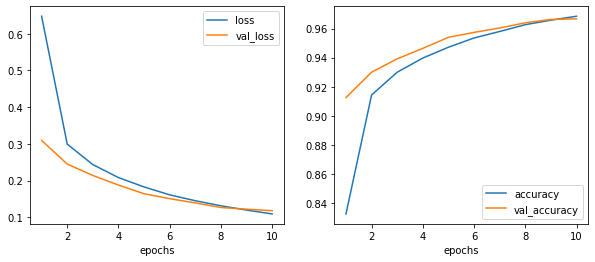

In [46]:
printhistory(history)

In [47]:
model.summary()

Model: "mnistexample"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          multiple                  0         
_________________________________________________________________
dense_6 (Dense)              multiple                  235500    
_________________________________________________________________
dense_7 (Dense)              multiple                  30100     
_________________________________________________________________
dense_8 (Dense)              multiple                  1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [48]:
Xnew=Xt[10:20]
ynew=yt[10:20]
yproba=model.predict(Xnew)
print(yproba.round(2))

[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.99]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.02 0.   0.97 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.99]
 [0.   0.   0.   0.01 0.   0.   0.   0.99 0.   0.  ]
 [0.   0.   0.04 0.94 0.   0.   0.   0.   0.02 0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]]


In [49]:
print(ynew)

[0 6 9 0 1 5 9 7 3 4]


In [50]:
# Not sure how to make the model class to inherent the predict_classes method.
#yproba2=model.predict_classes(Xnew)
#print(yproba2)
print(yproba.shape)
print(np.argmax(yproba,axis=1))

(10, 10)
[0 6 9 0 1 5 9 7 3 4]


### Exercise 5 - Regression MLP
Use the california_housing data set we used earlier in the course with linear regression and compare with MLP.

In [51]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [52]:
print(housing.data[0:2])
print(X_train[0:2,:])
print(y_train[0:2])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]
[[-0.19397883 -1.07781319 -0.94338545  0.01485314  0.02073335 -0.57291624
   0.92926047 -1.42215523]
 [ 0.75198318 -1.868895    0.40547793 -0.23327682  1.8614649   0.20516532
  -0.91654738  1.09666969]]
[1.442 1.687]


In [53]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(lr=1e-3))
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))


Train on 11610 samples, validate on 3870 samples
Epoch 1/20
11610/11610 [==============================] - 1s 82us/sample - loss: 2.0442 - val_loss: 1.0113
Epoch 2/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.8008 - val_loss: 0.7099
Epoch 3/20
11610/11610 [==============================] - 1s 57us/sample - loss: 0.6906 - val_loss: 0.8622
Epoch 4/20
11610/11610 [==============================] - 1s 56us/sample - loss: 0.6565 - val_loss: 0.6287
Epoch 5/20
11610/11610 [==============================] - 1s 58us/sample - loss: 0.6239 - val_loss: 0.6484
Epoch 6/20
11610/11610 [==============================] - 1s 57us/sample - loss: 0.5986 - val_loss: 0.6893
Epoch 7/20
11610/11610 [==============================] - 1s 56us/sample - loss: 0.5783 - val_loss: 0.5570
Epoch 8/20
11610/11610 [==============================] - 1s 57us/sample - loss: 0.5576 - val_loss: 0.5552
Epoch 9/20
11610/11610 [==============================] - 1s 56us/sample - loss: 0.5403 - val_l

In [54]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

NameError: name 'pd' is not defined

In [ ]:
mse_test = model.evaluate(X_test, y_test)
nsamples=-1
X_new = X_test[:nsamples]
y_new = y_test[:nsamples]
mse_new = model.evaluate(X_new, y_new)
y_pred = model.predict(X_new)
print('predicted',np.round(y_pred.T,2))
print('true      ',np.round(y_new,2))

In [ ]:
print(mse_test)

Let us save the model and restore to a new instance of model.

In [ ]:
model.save("my_keras_model.h5")

In [ ]:
model2 = keras.models.load_model("my_keras_model.h5")

In [ ]:
mse_new = model.evaluate(X_new, y_new)
mse_new2 = model2.evaluate(X_new, y_new)
y_pred2 = model2.predict(X_new)
print('predicted',np.round(y_pred.T,2))
print('true      ',np.round(y_pred2.T,2))

### Exercise 6: Using CallBacks

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

In [ ]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5") # rollback to best model
mse_test = model.evaluate(X_test, y_test)

In [ ]:
plt.plot(pd.DataFrame(history.history))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

### Exercise 7: Using tensorboard

In [ ]:
root_logdir = os.path.join(os.curdir, "my_logs")
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()
run_logdir

In [ ]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))

In [ ]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, tensorboard_cb])

To start the TensorBoard server, one option is to open a terminal, if needed activate the virtualenv where you installed TensorBoard, go to this notebook's directory, then type:

```bash
$ tensorboard --logdir=./my_logs --port=6006
```

You can then open your web browser to [localhost:6006](http://localhost:6006) and use TensorBoard. Once you are done, press Ctrl-C in the terminal window, this will shutdown the TensorBoard server.

Alternatively, you can load TensorBoard's Jupyter extension and run it like this:

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006